<h1 style="color: #25a890; font-size: 2.2em; margin-bottom: 5px; font-weight: 700;">Customer Segmentation | Preprocessing</h1>

<p style="margin: 3px 0; font-size: 1.1em; font-weight: 600;">NOVA IMS <span style="font-weight: 300;">| Machine Learning II</span></p>
<p style="margin: 3px 0; font-size: 0.95em;"><strong">Professors</strong> Fernando Bação & Ivo Bernardo</p>


<br>
<table style="width: 100%; border-collapse: collapse; font-size: 1em;">
    <tr>
        <td style="padding: 4px 0; font-weight: 500;">Diogo Gonçalves</td>
        <td style="padding: 4px 0; text-align: right; font-family: monospace;">(20241817)</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: 500;">Gustavo Franco</td>
        <td style="padding: 4px 0; text-align: right; font-family: monospace;">(20241806)</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: 500;">Simão Costa</td>
        <td style="padding: 4px 0; text-align: right; font-family: monospace;">(20241772)</td>
    </tr>


  

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;">Table of Contents</h3>
<div style="font-family: Arial, sans-serif; line-height: 1.8; margin-bottom: 30px; padding-left: 10px;">
    <ol style="margin-top: 0; padding-left: 20px;">
        <li><a href="#library-imports" style="color: #25a890; text-decoration: none; font-weight: 500;">Library Imports</a></li>
        <li><a href="#data-imports" style="color: #25a890; text-decoration: none; font-weight: 500;">Data Imports</a></li>
        <li>
            <a href="#data-cleaning" style="color: #25a890; text-decoration: none; font-weight: 500;">Data Cleaning</a>
            <ul style="list-style-type: circle; padding-left: 20px; margin-top: 5px; margin-bottom: 5px;">
                <li><a href="#duplicates" style="color: #25a890; text-decoration: none;">Missing Values</a></li>
                <li><a href="#variable-consistency" style="color: #25a890; text-decoration: none;">Transformation of Variables</a></li>
            </ul>
        </li>
        <li><a href="#correlation-between-variables" style="color: #25a890; text-decoration: none; font-weight: 500;">Feature Engineering</a></li>
        <li><a href="#correlation-between-variables" style="color: #25a890; text-decoration: none; font-weight: 500;">Scaling</a></li>
        <li><a href="#correlation-between-variables" style="color: #25a890; text-decoration: none; font-weight: 500;">Export</a></li>
    </ol>
</div>

<h2 style="color: #25a890; margin-bottom: 5px; font-weight: 700;">Library Imports</h2>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


<h2 style="color: #25a890; margin-bottom: 5px; font-weight: 700;">Data Import</h2>

In [2]:
cust_info=pd.read_csv('customer_info.csv')
cust_info=cust_info.set_index('customer_id')
cust_info.head(10)

,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
customer_id,,,,,,,,,,,,,,,,,,,,,
3,Bsc. Crystal Kitchens,female,02/12/1970 01:36 PM,1.0,1.0,1.0,3.0,11731.0,4553.0,NaN,...,213.0,552.0,256.0,384.0,189.0,0.631599,2020.0,1.0,38.794428,-9.215739
4,Bsc. Glenda Bauman,female,11/13/1975 06:58 PM,1.0,0.0,0.0,2.0,13694.0,963.0,NaN,...,15.0,1880.0,333.0,665.0,130.0,0.149890,2013.0,1.0,38.751711,-9.179611
5,Msc. Antonio Campbell,male,09/10/1971 10:07 AM,0.0,0.0,NaN,2.0,12407.0,0.0,11.0,...,273.0,507.0,101.0,222.0,81.0,0.069126,2005.0,NaN,38.780678,-9.160656
7,John Kelling,male,10/23/1982 11:20 AM,0.0,0.0,2.0,1.0,7493.0,1105.0,18.0,...,1083.0,485.0,1656.0,184.0,92.0,0.253609,2021.0,1.0,38.739548,-9.148679
8,Arthur Dematteo,male,08/04/1969 10:22 PM,0.0,0.0,3.0,1.0,9187.0,10841.0,17.0,...,1015.0,297.0,1258.0,441.0,6.0,0.186569,2021.0,1.0,38.733071,-9.188188
9,Msc. Nadine Garcia,female,10/09/1968 04:01 AM,1.0,1.0,1.0,6.0,16530.0,1156.0,6.0,...,76.0,513.0,225.0,NaN,84.0,0.150646,2011.0,1.0,38.735577,-9.172423
10,Phd. Franklin Alba,male,06/09/1971 05:08 AM,2.0,1.0,0.0,1.0,22240.0,NaN,9.0,...,1723.0,886.0,203.0,119.0,202.0,0.275412,2014.0,1.0,38.730322,-9.144022
11,Bsc. Robert Hansing,male,07/19/1977 10:22 AM,1.0,1.0,1.0,6.0,29765.0,1543.0,10.0,...,731.0,1240.0,1849.0,397.0,180.0,0.164251,2017.0,1.0,38.739328,-9.225047
12,Phd. Dorothy Pacheco,female,05/19/2000 03:02 AM,0.0,0.0,0.0,2.0,9281.0,254.0,18.0,...,598.0,673.0,71.0,64.0,29.0,-0.131176,2018.0,NaN,38.748616,-9.167756


<h2 style="color: #25a890; margin-bottom: 5px; font-weight: 700;">Missing Values</h2>

In [3]:
cust_info.isna().sum()

customer_name                                  0
customer_gender                                0
customer_birthdate                           165
kids_home                                    330
teens_home                                   330
number_complaints                            661
distinct_stores_visited                      330
lifetime_spend_groceries                       0
lifetime_spend_electronics                   661
typical_hour                                 661
lifetime_spend_vegetables                    661
lifetime_spend_nonalcohol_drinks               0
lifetime_spend_alcohol_drinks                330
lifetime_spend_meat                          661
lifetime_spend_fish                          991
lifetime_spend_hygiene                       330
lifetime_spend_videogames                    661
lifetime_spend_petfood                       661
lifetime_total_distinct_products               0
percentage_of_products_bought_promotion      330
year_first_transacti

In [4]:
p_of_mv = cust_info.isna().sum() / len(cust_info) * 100
print(p_of_mv.round(2).astype(str) + "%")

customer_name                                0.0%
customer_gender                              0.0%
customer_birthdate                           0.5%
kids_home                                    1.0%
teens_home                                   1.0%
number_complaints                            2.0%
distinct_stores_visited                      1.0%
lifetime_spend_groceries                     0.0%
lifetime_spend_electronics                   2.0%
typical_hour                                 2.0%
lifetime_spend_vegetables                    2.0%
lifetime_spend_nonalcohol_drinks             0.0%
lifetime_spend_alcohol_drinks                1.0%
lifetime_spend_meat                          2.0%
lifetime_spend_fish                          3.0%
lifetime_spend_hygiene                       1.0%
lifetime_spend_videogames                    2.0%
lifetime_spend_petfood                       2.0%
lifetime_total_distinct_products             0.0%
percentage_of_products_bought_promotion      1.0%


In [5]:
cust_info['customer_birthdate'] = pd.to_datetime(cust_info['customer_birthdate'], format='%m/%d/%Y %I:%M %p')
reference_date = pd.Timestamp.today()
cust_info['age'] = (reference_date - cust_info['customer_birthdate']).dt.days // 365

cust_info['age'] = cust_info['age'].fillna(cust_info['age'].median())
cust_info = cust_info.drop(columns=['customer_birthdate'])

cols_to_impute = [
    'kids_home', 'teens_home', 'number_complaints',
    'distinct_stores_visited', 'lifetime_spend_electronics', 'typical_hour',
    'lifetime_spend_vegetables', 'lifetime_spend_alcohol_drinks', 'lifetime_spend_meat',
    'lifetime_spend_fish', 'lifetime_spend_hygiene', 'lifetime_spend_videogames',
    'lifetime_spend_petfood', 'percentage_of_products_bought_promotion',
    'lifetime_spend_nonalcohol_drinks', 'lifetime_spend_groceries',
    'lifetime_total_distinct_products', 'year_first_transaction'
]

imputer = SimpleImputer(strategy='median')
cust_info[cols_to_impute] = imputer.fit_transform(cust_info[cols_to_impute])

In [6]:
cust_info.isna().sum()

customer_name                                  0
customer_gender                                0
kids_home                                      0
teens_home                                     0
number_complaints                              0
distinct_stores_visited                        0
lifetime_spend_groceries                       0
lifetime_spend_electronics                     0
typical_hour                                   0
lifetime_spend_vegetables                      0
lifetime_spend_nonalcohol_drinks               0
lifetime_spend_alcohol_drinks                  0
lifetime_spend_meat                            0
lifetime_spend_fish                            0
lifetime_spend_hygiene                         0
lifetime_spend_videogames                      0
lifetime_spend_petfood                         0
lifetime_total_distinct_products               0
percentage_of_products_bought_promotion        0
year_first_transaction                         0
loyalty_card_number 

<h2 style="color: #25a890; margin-bottom: 5px; font-weight: 700;">Transformations of Variables</h2>

<h3 style="color: #25a890; margin-bottom: 5px; font-weight: 700;"><code style="color: #25a890;">customer_name</code></h3>


In [7]:
cust_info['education_level'] = cust_info['customer_name'].str.extract(r'^(Bsc|Msc|Phd)\.').fillna('None')
cust_info['customer_name'] = cust_info['customer_name'].str.replace(r'^(Bsc|Msc|Phd)\.\s*', '', regex=True)

In [8]:
cust_info[['customer_name', 'education_level']].head(10)

,customer_name,education_level
customer_id,,
3,Crystal Kitchens,Bsc
4,Glenda Bauman,Bsc
5,Antonio Campbell,Msc
7,John Kelling,None
8,Arthur Dematteo,None
9,Nadine Garcia,Msc
10,Franklin Alba,Phd
11,Robert Hansing,Bsc
12,Dorothy Pacheco,Phd


<p style="color: #25a890;">We extracted the education level from the <code style="color: #25a890;">customer_name</code> column into a new <code style="color: #25a890;">education_level</code> column, filling customers without a prefix with <code style="color: #25a890;">'None'</code>. It then cleans the <code style="color: #25a890;">customer_name</code> column by removing the prefix, leaving only the actual name.</p>

<h3 style="color: #25a890; margin-bottom: 5px; font-weight: 700;"><code style="color: #25a890;">customer_birthdate</code></h3>

In [9]:
print(cust_info['age'].describe())
print(f"Missing ages: {cust_info['age'].isna().sum()}")

count    33038.000000
mean        54.586960
std         18.038991
min         24.000000
25%         39.000000
50%         54.000000
75%         70.000000
max         86.000000
Name: age, dtype: float64
Missing ages: 0


<h3 style="color: #25a890; margin-bottom: 5px; font-weight: 700;"><code style="color: #25a890;">percentage_of_products_bought_promotion</code></h3>

<p style="color: #25a890;">Percentage of products bought on promotion have less than 0%</p>

In [10]:
mask = cust_info['percentage_of_products_bought_promotion'] < 0
count = mask.sum()
percentage = mask.mean() * 100

print(f"Count: {count}")
print(f"Percentage: {percentage:.2f}%")

Count: 1755
Percentage: 5.31%


In [11]:
cust_info['percentage_of_products_bought_promotion'] = cust_info['percentage_of_products_bought_promotion'].where(cust_info['percentage_of_products_bought_promotion'] >= 0, cust_info['percentage_of_products_bought_promotion'] * -1)


<h3 style="color: #25a890; margin-bottom: 5px; font-weight: 700;"><code style="color: #25a890;">year_first_transaction</code></h3>

In [12]:
year_counts = cust_info['year_first_transaction'].value_counts().sort_index()
total = len(cust_info)

# --- classify years ---
def classify(year):
    if year < 2000:
        return 'pre2000'
    elif year > 2025:
        return 'future'
    elif year == 2021:
        return 'spike'
    else:
        return 'normal'

colors = [
    '#E24B4A' if classify(y) == 'future'  else
    '#EF9F27' if classify(y) == 'pre2000' else
    '#EF9F27' if classify(y) == 'spike'   else
    '#378ADD'
    for y in year_counts.index
]


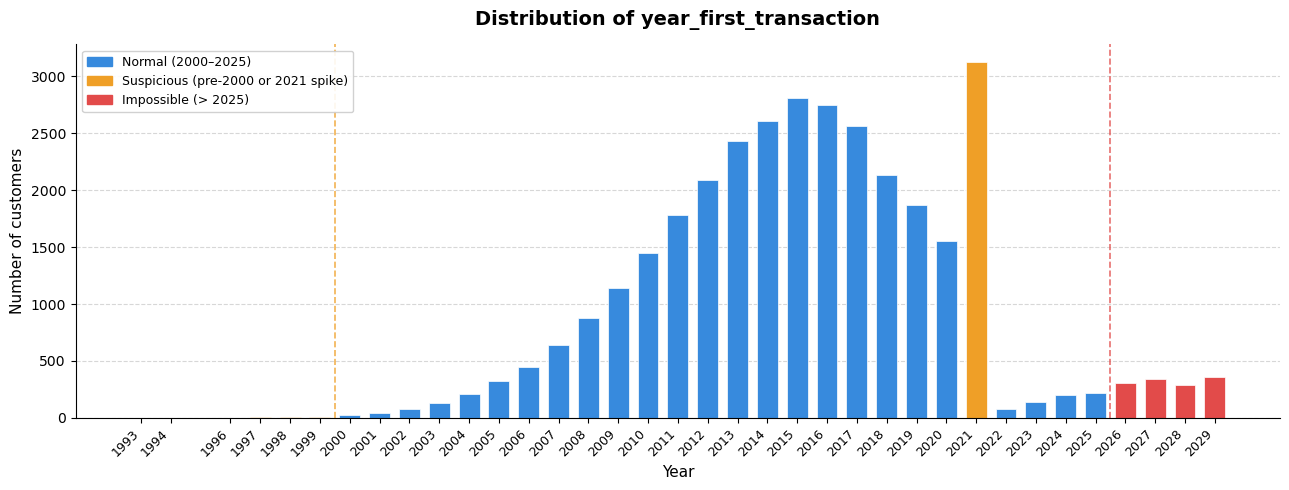

In [13]:
fig, ax = plt.subplots(figsize=(13, 5))

bars = ax.bar(year_counts.index.astype(int), year_counts.values, color=colors, width=0.7, edgecolor='white', linewidth=0.5)

ax.set_title('Distribution of year_first_transaction', fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Number of customers', fontsize=11)
ax.set_xticks(year_counts.index.astype(int))
ax.set_xticklabels(year_counts.index.astype(int), rotation=45, ha='right', fontsize=9)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)

# --- vertical dividers ---
ax.axvline(x=1999.5, color='#EF9F27', linestyle='--', linewidth=1.2, alpha=0.8)
ax.axvline(x=2025.5, color='#E24B4A', linestyle='--', linewidth=1.2, alpha=0.8)

legend_handles = [
    mpatches.Patch(color='#378ADD', label='Normal (2000–2025)'),
    mpatches.Patch(color='#EF9F27', label='Suspicious (pre-2000 or 2021 spike)'),
    mpatches.Patch(color='#E24B4A', label='Impossible (> 2025)'),
]
ax.legend(handles=legend_handles, fontsize=9, loc='upper left', framealpha=0.9)

plt.tight_layout()
plt.show()

In [14]:
pre2000  = (cust_info['year_first_transaction'] < 2000).sum()
future   = (cust_info['year_first_transaction'] > 2025).sum()
spike    = (cust_info['year_first_transaction'] == 2021).sum()
normal   = ((cust_info['year_first_transaction'] >= 2000) & (cust_info['year_first_transaction'] <= 2025)).sum()

print("=" * 45)
print(f"{'Category':<30} {'Rows':>6}  {'% total':>7}")
print("-" * 45)
print(f"{'Normal (2000–2025)':<30} {normal:>6,}  {normal/total*100:>6.1f}%")
print(f"{'2021 spike':<30} {spike:>6,}  {spike/total*100:>6.1f}%")
print(f"{'Pre-2000 (likely errors)':<30} {pre2000:>6,}  {pre2000/total*100:>6.1f}%")
print(f"{'Future dates > 2025':<30} {future:>6,}  {future/total*100:>6.1f}%")
print("=" * 45)
print(f"{'Total':<30} {total:>6,}  {'100.0%':>7}")

Category                         Rows  % total
---------------------------------------------
Normal (2000–2025)             31,713    96.0%
2021 spike                      3,125     9.5%
Pre-2000 (likely errors)           29     0.1%
Future dates > 2025             1,296     3.9%
Total                          33,038   100.0%


In [15]:
cust_info['year_first_transaction'] = cust_info['year_first_transaction'].clip(upper=2026)

cust_info['year_first_transaction'] = cust_info['year_first_transaction'].clip(lower=2000)

<h3 style="color: #25a890; margin-bottom: 5px; font-weight: 700;"><code style="color: #25a890;">loyalty_card_number</code></h3>

<p style="color: #25a890;">Number of people with loyalty card</p>


In [16]:
print(cust_info['loyalty_card_number'].value_counts())

loyalty_card_number
1.0    19932
Name: count, dtype: int64


<p style="color: #25a890;">Number of people without loyalty card = null values in loyalty_card_number</p>


In [17]:
cust_info['loyalty_card_number'].isnull().sum()

np.int64(13106)

<p style="color: #25a890;">Almost 50% of the customers have a loyalty card, so I will create a binary feature for that instead of dropping the column</p>


In [18]:
cust_info['has_loyalty_card'] = cust_info['loyalty_card_number'].notna().astype(int)
print(cust_info['has_loyalty_card'].value_counts())

has_loyalty_card
1    19932
0    13106
Name: count, dtype: int64


In [19]:
cust_info = cust_info.drop(columns=['loyalty_card_number'])
cust_info['has_loyalty_card'].head(10)

customer_id
3     1
4     1
5     0
7     1
8     1
9     1
10    1
11    1
12    0
14    1
Name: has_loyalty_card, dtype: int64

<h2 style="color: #25a890; margin-bottom: 5px; font-weight: 700;">Feature Engeneering</h2>

<br>

<table style="color: #25a890;">
<thead>
<tr><th>Feature</th><th>Formula</th><th>Interpretation</th></tr>
</thead>
<tbody>
<tr><td><code style="color: #25a890;">fresh_food_ratio</code></td><td><code style="color: #25a890;">(lifetime_spend_vegetables + lifetime_spend_meat + lifetime_spend_fish) / total_spend</code></td><td>Proportion of total spend on fresh food</td></tr>
<tr><td><code style="color: #25a890;">spend_per_store</code></td><td><code style="color: #25a890;">lifetime_spend_groceries / distinct_stores_visited</code></td><td>Average grocery spend per store visited</td></tr>
<tr><td><code style="color: #25a890;">promotion_guy</code></td><td><code style="color: #25a890;">total_spend × percentage_of_products_bought_promotion</code></td><td>High spenders that are still promotion-driven</td></tr>
<tr><td><code style="color: #25a890;">progenitores</code></td><td><code style="color: #25a890;">kids_home + teens_home</code></td><td>Total number of dependents at home</td></tr>
<tr><td><code style="color: #25a890;">tech_enthusiast</code></td><td><code style="color: #25a890;">(lifetime_spend_electronics + lifetime_spend_videogames) / lifetime_spend_groceries</code></td><td>Buys lots of tech</td></tr>
<tr><td><code style="color: #25a890;">healthy_guy</code></td><td><code style="color: #25a890;">(lifetime_spend_vegetables + lifetime_spend_fish) / (lifetime_spend_meat + lifetime_spend_alcohol_drinks + lifetime_spend_groceries)</code></td><td>Customers that buy healthy food</td></tr>
<tr><td><code style="color: #25a890;">loyal_long_timer</code></td><td><code style="color: #25a890;">(reference_date - year_first_transaction) * has_loyalty_card</code></td><td>A customer that joined early and has a loyalty card</td></tr>
</tbody>
</table>

In [20]:
# Fresh food ratio
cust_info['fresh_food_ratio'] = (cust_info['lifetime_spend_vegetables'] + cust_info['lifetime_spend_meat'] + cust_info['lifetime_spend_fish']) / cust_info['lifetime_spend_groceries']

# Spend per store
cust_info['spend_per_store'] = cust_info['lifetime_spend_groceries'] / cust_info['distinct_stores_visited']

# Promotion guy
cust_info['promotion_guy'] = cust_info['lifetime_spend_groceries'] * cust_info['percentage_of_products_bought_promotion']

# Progenitores
cust_info['progenitores'] = cust_info['kids_home'] + cust_info['teens_home']

# Tech enthusiast
cust_info['tech_enthusiast'] = (cust_info['lifetime_spend_electronics'] + cust_info['lifetime_spend_videogames'])/cust_info['lifetime_spend_groceries']

# Healthy guy
cust_info['healthy_guy'] = (cust_info['lifetime_spend_vegetables'] + cust_info['lifetime_spend_fish'])/cust_info['lifetime_spend_groceries']

# Loyal long timer
cust_info['loyal_long_timer'] = (reference_date.year - cust_info['year_first_transaction']) * cust_info['has_loyalty_card']

In [21]:
cust_info.head(10)

,customer_name,customer_gender,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,...,age,education_level,has_loyalty_card,fresh_food_ratio,spend_per_store,promotion_guy,progenitores,tech_enthusiast,healthy_guy,loyal_long_timer
customer_id,,,,,,,,,,,,,,,,,,,,,
3,Crystal Kitchens,female,1.0,1.0,1.0,3.0,11731.0,4553.0,12.0,373.0,...,56.0,Bsc,1,0.052340,3910.333333,7409.284808,2.0,0.409939,0.049953,6.0
4,Glenda Bauman,female,1.0,0.0,0.0,2.0,13694.0,963.0,12.0,2012.0,...,50.0,Bsc,1,0.151161,6847.000000,2052.597074,1.0,0.094640,0.148021,13.0
5,Antonio Campbell,male,0.0,0.0,1.0,2.0,12407.0,0.0,11.0,555.0,...,54.0,Msc,0,0.168695,6203.500000,857.640165,0.0,0.008141,0.066737,0.0
7,John Kelling,male,0.0,0.0,2.0,1.0,7493.0,1105.0,18.0,84.0,...,43.0,None,1,0.285466,7493.000000,1900.294191,0.0,0.368477,0.155745,5.0
8,Arthur Dematteo,male,0.0,0.0,3.0,1.0,9187.0,10841.0,17.0,380.0,...,56.0,None,1,0.268096,9187.000000,1714.006967,0.0,1.316970,0.151845,5.0
9,Nadine Garcia,female,1.0,1.0,1.0,6.0,16530.0,1156.0,6.0,1708.0,...,57.0,Msc,1,0.109558,2755.000000,2490.172765,2.0,0.083545,0.107925,15.0
10,Franklin Alba,male,2.0,1.0,0.0,1.0,22240.0,1470.0,9.0,1284.0,...,55.0,Phd,1,0.198022,22240.000000,6125.169048,3.0,0.075225,0.135207,12.0
11,Robert Hansing,male,1.0,1.0,1.0,6.0,29765.0,1543.0,10.0,190.0,...,48.0,Bsc,1,0.060205,4960.833333,4888.930791,2.0,0.113959,0.030942,9.0
12,Dorothy Pacheco,female,0.0,0.0,0.0,2.0,9281.0,254.0,18.0,125.0,...,26.0,Phd,0,0.092878,4640.500000,1217.444870,0.0,0.035018,0.077901,0.0


<p style="color: #25a890;">Infinite Values</p>

In [22]:
ratio_features = ['fresh_food_ratio', 'spend_per_store', 'healthy_guy', 'tech_enthusiast']

mask = cust_info[ratio_features].isin([np.inf, -np.inf]).any(axis=1)
print(f"Rows with infinity: {mask.sum()}")
cust_info[mask][ratio_features]

Rows with infinity: 1


,fresh_food_ratio,spend_per_store,healthy_guy,tech_enthusiast
customer_id,,,,
39364,inf,0.0,inf,inf


<p style="color: #25a890;">Sets all infinite values to 0</p>

In [23]:
cust_info = cust_info.replace([np.inf, -np.inf], 0)

<p style="color:#25a890;"> Save the dataset for to keep the information already with the features</p>

In [24]:
cust_info.to_csv('cust_info_engineered.csv', index=True)

<h2 style="color: #25a890; margin-bottom: 5px; font-weight: 700;">Scaling</h2>

In [25]:
cluster_features = [
    'age',
    'number_complaints',
    'progenitores',                      # replaces kids_home + teens_home
    'spend_per_store',                   # replaces groceries + distinct_stores_visited
    'fresh_food_ratio',                  # replaces vegetables + meat + fish
    'healthy_guy',                       # replaces vegetables + fish individually
    'tech_enthusiast',                    # replaces lifetime_spend_alcohol_drinks
    'lifetime_spend_nonalcohol_drinks',
    'lifetime_spend_hygiene',
    'lifetime_spend_petfood',
    'lifetime_total_distinct_products',
    'percentage_of_products_bought_promotion',
    'promotion_guy',
    'has_loyalty_card',
    'loyal_long_timer',
    'typical_hour',                      
]

X = cust_info[cluster_features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame( X_scaled, columns=cluster_features, index=cust_info.index)

X_scaled.head()

,age,number_complaints,progenitores,spend_per_store,fresh_food_ratio,healthy_guy,tech_enthusiast,lifetime_spend_nonalcohol_drinks,lifetime_spend_hygiene,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,promotion_guy,has_loyalty_card,loyal_long_timer,typical_hour
customer_id,,,,,,,,,,,,,,,,
3,0.078334,0.076516,-0.008390,-0.445128,-0.071029,-0.062147,-0.031539,-0.512586,-0.441031,0.302391,0.378445,1.125696,0.297450,0.810886,-0.116397,-0.134436
4,-0.254284,-1.052532,-0.572901,-0.008371,-0.051019,-0.035426,-0.070468,0.248935,1.752524,2.073845,-0.178573,-0.678516,-0.491317,0.810886,0.922055,-0.134436
5,-0.032539,0.076516,-1.137412,-0.104076,-0.047469,-0.057574,-0.081147,-1.317623,-0.515361,-0.718874,-0.641180,-0.981016,-0.667273,-1.233219,-1.006499,-0.342479
7,-0.642338,1.205564,-1.137412,0.087705,-0.023824,-0.033321,-0.036658,1.061224,-0.551700,-0.958430,-0.537330,-0.290042,-0.513743,0.810886,-0.264748,1.113819
8,0.078334,2.334612,-1.137412,0.339646,-0.027341,-0.034384,0.080449,0.462886,-0.862233,0.661725,-1.349253,-0.541139,-0.541174,0.810886,-0.264748,0.905776


<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> PCA </h3>

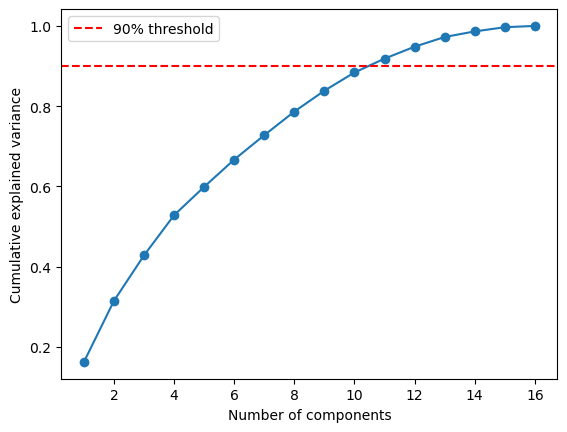

In [26]:
pca = PCA()
pca.fit(X_scaled)

cumvar = np.cumsum(pca.explained_variance_ratio_)
plt.plot(range(1, len(cumvar)+1), cumvar, marker='o')
plt.axhline(0.9, linestyle='--', color='red', label='90% threshold')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.legend()
plt.show()

<p style="color: #25a890; font-size: 0.9em;">Around 11 variables explain 90% of the variance, so PCA might be applied to remove redundancy and noise</p>

In [27]:
pca = PCA(n_components=11, random_state=42)
X_pca = pca.fit_transform(X_scaled)
X_pca = pd.DataFrame(X_pca, index=X_scaled.index)

print(f"Explained variance: {pca.explained_variance_ratio_.sum():.2%}")

Explained variance: 91.85%


<h2 style="color: #25a890; margin-bottom: 5px; font-weight: 700;">Export</h2>

<p style="color: #25a890; font-size: 0.9em;">Here we export the cleaned and scaled data, ready for modeling</p>

In [28]:
X_scaled.to_csv('X_scaled.csv', index=True)